<a href="https://colab.research.google.com/github/Kevin-gram/Sentiment-Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import all necessary libraries

Imports necessary libraries like pandas, scikit-learn, nltk, re, matplotlib, and seaborn for data manipulation, model building, text processing, and visualization.

In [1]:
# importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import re
import matplotlib.pyplot as plt
import seaborn as sns

Loads the dataset from a CSV file named 'hate.csv' using pandas and displays its shape (number of rows and columns).

In [2]:
# Load the dataset
dataset = pd.read_csv('hate.csv', encoding='latin-1')
dataset.shape

(41144, 3)

 Shows the first few rows of the dataset using head().

In [3]:
dataset.head()

,Unnamed: 0,comment,label
0,1,dalits are lowlives,N
1,2,gay people are a burden to our society,N
2,3,Arabs are not welcome,N
3,4,I'm not saying we should actually eliminate he...,N
4,5,bananas are for black people,N


Displays the last few rows of the dataset using tail().

In [4]:
dataset.tail()

,Unnamed: 0,comment,label
41139,117100,Indian culture is so backwards,N
41140,118100,"Women don't want equality, they just want to b...",N
41141,119100,fuck covid,P
41142,1205,This computer is garbage,P
41143,121100,The only good Muslim is a dead one,N


Provides information about the dataset, including column names, data types, and non-null values, using info()

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41144 entries, 0 to 41143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  41144 non-null  int64 
 1   comment     41144 non-null  object
 2   label       41144 non-null  object
dtypes: int64(1), object(2)
memory usage: 964.4+ KB


Shows descriptive statistics of the dataset using describe(), including count, mean, standard deviation, etc.

In [6]:
# check statistical measures
dataset.describe(include = 'all')

,Unnamed: 0,comment,label
count,41144.000000,41144,41144
unique,NaN,41134,3
top,NaN,Blacks are such pondlife,N
freq,NaN,5,22158
mean,20703.991056,NaN,NaN
std,12580.884040,NaN,NaN
min,1.000000,NaN,NaN
25%,10295.750000,NaN,NaN
50%,20593.500000,NaN,NaN
75%,30894.250000,NaN,NaN


Checks for missing values (null values) in each column using isnull().sum().

In [7]:
# check for null values
dataset.isnull().sum()

,0
Unnamed: 0,0
comment,0
label,0


Counts the number of unique values in each column using nunique().

In [8]:
# check unique values
dataset.nunique()

,0
Unnamed: 0,41144
comment,41134
label,3


Specifically counts the unique values in the 'label' column.

In [9]:
dataset.nunique()['label']

3

Shows the frequency of each unique value in the 'label' column using value_counts().

In [10]:
dataset.value_counts('label')

,count
label,
N,22158
P,18950
O,36


Creates a bar plot to visualize the distribution of the 'label' column.

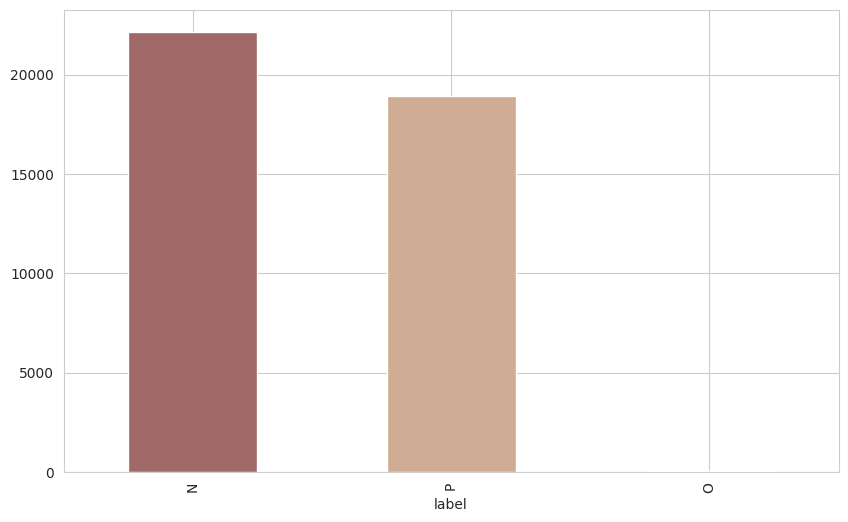

In [11]:
# Define figure size and style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the bar plot with better aesthetics
ax = dataset['label'].value_counts().plot(kind='bar', color=sns.color_palette("pink", len(dataset['label'].unique())))


 Shows the frequency of each unique value in the 'comment' column.

In [12]:
dataset.value_counts('comment')

,count
comment,
Blacks are such pondlife,5
Muslims are a disgrace,3
Politicians are crap,2
Politicians are scum,2
I endorse the genocide of Muslims,2
...,...
Illegal Immigrant could be charged With Raping Incapacitated Woman In Kentucky. Shouldn't be released on bail,1
"Illegal Immigrant could be charged With Raping Incapacitated Woman In Kentucky. Shouldn't be released on bail, rightly so, as they probably took 'no' was 'yes' as their women are like slaves to them.",1
Illegal alien invaders* sounds more like it,1


Downloads necessary resources for NLTK (Natural Language Toolkit), including 'punkt' and 'stopwords'.

In [13]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

 Defines a function called preprocess_text to clean and prepare text data. This includes converting to lowercase, removing special characters, tokenization, removing stop words, and stemming. It then applies this function to the 'comment' column and stores the results in a new column called 'preprocessed_tex

In [14]:
# Preprocessing function
import nltk
nltk.download('punkt_tab')
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]

    # Join tokens back into text
    preprocessed_text = ' '.join(tokens)

    return preprocessed_text

# Apply preprocessing to the dataset
dataset['preprocessed_text'] = dataset['comment'].apply(preprocess_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Prints the shapes (number of rows and columns) of the training and testing sets (X_train, X_test, y_train, y_test).

In [15]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(dataset['preprocessed_text'], dataset['label'], test_size=0.2, random_state=42)


Prints the shapes (number of rows and columns) of the training and testing sets (X_train, X_test, y_train, y_test).

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(32915,)
(8229,)
(32915,)
(8229,)


### BERT-Based Text Classification
This notebook initializes a BERT tokenizer and model for sequence classification with three possible labels, leveraging the transformers library.

In [17]:

from transformers import BertTokenizer, BertForSequenceClassification, AdamW
import torch

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### BERT-Based Text Classification: Data Preparation and Processing  

**Explanation:** to prepare text data for BERT-based classification:  

1. **Load Pretrained BERT Model & Tokenizer** – Initialize a tokenizer and model from `bert-base-uncased` for sequence classification with three labels.  
2. **Convert Text Data for Model Input** – Tokenize training and test datasets (`X_train`, `X_test`) using BERT's tokenizer, ensuring proper formatting with padding and truncation.  
3. **Prepare Inputs for Training** – Convert tokenized outputs into PyTorch tensors (`return_tensors="pt"`) for model compatibility.  

Each step ensures the text data is properly processed for BERT classification.

In [18]:
# Convert text data to input format for BERT
inputs_train = tokenizer(X_train.tolist(), padding=True, truncation=True, return_tensors="pt")
inputs_test = tokenizer(X_test.tolist(), padding=True, truncation=True, return_tensors="pt")

inputs_train is a dictionary containing tokenized representations of your training data, formatted for input into a BERT model.

**Text Classification with Support Vector Machine (SVM) using TF-IDF Vectorization**

**Explanation:**
In this step, a Support Vector Machine (SVM) with a linear kernel is used for the text classification task. The model pipeline includes TF-IDF vectorization to transform text data into numerical features, followed by training an SVM classifier. After training the model on the training data, predictions are made on the test set. The performance is evaluated using accuracy and a detailed classification report, which includes precision, recall, and F1-score, providing insights into the model's classification capabilities.

In [19]:
inputs_train

{'input_ids': tensor([[  101,  2132,  6616,  ...,     0,     0,     0],
        [  101, 10047,  2175,  ...,     0,     0,     0],
        [  101,  6752,  2072,  ...,     0,     0,     0],
        ...,
        [  101,  5413,  2229,  ...,     0,     0,     0],
        [  101, 25386,  4995,  ...,     0,     0,     0],
        [  101,  2115,  9643,  ...,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define the pipeline with TF-IDF, normalization, and early stopping
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into TF-IDF vectors
    ('scaler', MaxAbsScaler()),  # Normalize features while keeping data sparse
    ('sgd', SGDClassifier(loss='hinge',  # Similar to SVM (hinge loss)
                          max_iter=1000,  # Maximum iterations
                          tol=1e-3,  # Stop when improvement is below threshold
                          early_stopping=False,  # Enables early stopping
                          validation_fraction=0.1,  # 10% of training used for validation
                          n_iter_no_change=5,  # Stop if no improvement in 5 epochs
                          random_state=42))  # Ensure reproducibility
])

# Train the model with early stopping
model_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)


Accuracy: 0.632276096731073
Classification Report:
               precision    recall  f1-score   support

           N       0.64      0.69      0.67      4375
           O       0.00      0.00      0.00         4
           P       0.62      0.57      0.59      3850

    accuracy                           0.63      8229
   macro avg       0.42      0.42      0.42      8229
weighted avg       0.63      0.63      0.63      8229



In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.compose import ColumnTransformer

# Define the pipeline with scaling
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('scaler', MaxAbsScaler()),  # Scale the TF-IDF features
    ('svm', SVC(kernel='linear'))
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)


Accuracy: 0.6226759022967554
Classification Report:
               precision    recall  f1-score   support

           N       0.64      0.68      0.66      4375
           O       0.00      0.00      0.00         4
           P       0.61      0.56      0.58      3850

    accuracy                           0.62      8229
   macro avg       0.41      0.41      0.41      8229
weighted avg       0.62      0.62      0.62      8229



In [22]:
# Model selection and training
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Define the model pipeline
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm', SVC(kernel='linear'))
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Accuracy: 0.6692186170859157
Classification Report:
               precision    recall  f1-score   support

           N       0.68      0.71      0.69      4375
           O       0.00      0.00      0.00         4
           P       0.65      0.63      0.64      3850

    accuracy                           0.67      8229
   macro avg       0.45      0.44      0.44      8229
weighted avg       0.67      0.67      0.67      8229



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Compute classification performance metrics: accuracy, precision, recall, and F1-score
**Evaluating the Model Performance with Key Metrics**

**Explanation:**
In this step, the performance of the trained model is evaluated using several key metrics: accuracy, precision, recall, and F1-score. These metrics provide a comprehensive assessment of how well the model predicts the test set, with a focus on both overall accuracy and the balance between precision and recall. The weighted average is used to account for class imbalances, providing a more robust evaluation when dealing with multi-class classification tasks.


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# y_pred contains the predicted labels and y_test contains the true labels
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.6692186170859157
Precision: 0.6683366966789801
Recall: 0.6692186170859157
F1-score: 0.6685305167246044


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Train and evaluate a Random Forest model using TF-IDF features
**Text Classification with Random Forest Classifier using TF-IDF Vectorization**

**Explanation:**
In this step, a Random Forest Classifier is applied to the text classification task, with TF-IDF vectorization used to convert text data into numerical features. The model is trained on the training data and predictions are made on the test set. The model's performance is evaluated using accuracy and a detailed classification report, which provides insights into the model's precision, recall, and other performance metrics. This allows for a thorough evaluation of how well the Random Forest model performs compared to the Logistic Regression model.

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Define the model pipeline with Random Forest classifier
model_pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('rf', RandomForestClassifier())
])

# Train the model
model_pipeline_rf.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = model_pipeline_rf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Accuracy: 0.6692186170859157
Classification Report:
               precision    recall  f1-score   support

           N       0.68      0.71      0.69      4375
           O       0.00      0.00      0.00         4
           P       0.65      0.63      0.64      3850

    accuracy                           0.67      8229
   macro avg       0.45      0.44      0.44      8229
weighted avg       0.67      0.67      0.67      8229



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Text Classification with Logistic Regression using TF-IDF Vectorization**


In this step, we build a text classification model by applying Logistic Regression in combination with TF-IDF vectorization to transform the text data into numerical features. The model is trained on the training dataset, followed by predictions on the test set. The performance of the model is then evaluated using several metrics: accuracy, precision, recall, F1 score, and a detailed classification report. These evaluations help assess the model's effectiveness and identify areas for improvement.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define the model pipeline with Logistic Regression
model_pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegression())
])

# Train the model
model_pipeline_lr.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = model_pipeline_lr.predict(X_test)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_score_lr = f1_score(y_test, y_pred_lr, average='weighted')
classification_report_lr = classification_report(y_test, y_pred_lr)

# Print evaluation metrics
print("Evaluation Metrics for Logistic Regression Model:")
print("Accuracy:", accuracy_lr)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1 Score:", f1_score_lr)
print("\nClassification Report:")
print(classification_report_lr)

Evaluation Metrics for Logistic Regression Model:
Accuracy: 0.6671527524608093
Precision: 0.6661690324837957
Recall: 0.6671527524608093
F1 Score: 0.6661824269462965

Classification Report:
              precision    recall  f1-score   support

           N       0.68      0.71      0.69      4375
           O       0.00      0.00      0.00         4
           P       0.65      0.62      0.63      3850

    accuracy                           0.67      8229
   macro avg       0.44      0.44      0.44      8229
weighted avg       0.67      0.67      0.67      8229



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

**Saving the Trained Model using Joblib**

**Explanation:**
In this step, the trained Logistic Regression model, encapsulated within the pipeline, is saved to a file using the `joblib` library. This allows for the persistence of the model, enabling it to be easily loaded and reused for future predictions without the need for retraining. The model is saved in the `model.pkl` file for efficient storage and retrieval.

In [26]:
from joblib import dump

dump(model_pipeline_lr, 'model.pkl')

['model.pkl']


**Downloading the Saved Model from Colab**

**Explanation:**
In this step, the saved model file (`model.pkl`) is downloaded from the Colab environment to your local machine using the `files.download()` function. This provides a convenient way to transfer the trained model for use outside the Colab environment, such as for deployment or further analysis.

In [27]:
from google.colab import files

files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>